In [23]:
from rftrack.aux import plot_phase_space
from rftrack.data import parser_volume
import RF_Track as rft
import numpy as np

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import gaussian_kde

def plot_phase_space_4panel(
    x, xp, y, yp,
    filename="phase_space_4panel",
    save=True,
    units_already_mm_mrad=True,
    bw_method=0.5,
    point_size=5,
    alpha=0.85,
    cmap="viridis",
    label_fontsize=16,
    tick_fontsize=13,
    cbar_fontsize=13,
    figsize=(13, 10),
    plot_rms_ellipse=True,
    contain_fraction=0.90,
    ellipse_color="red",
    ellipse_lw=2.2,
    ellipse_label=True
):
    """
    Plotea en una figura 2x2:

        x  - x'
        y  - y'
        x  - y
        x' - y'

    Además, pinta la elipse RMS escalada para contener el 90% de las partículas
    en cada plano.

    Guarda el PDF en la carpeta actual.
    """

    x = np.asarray(x)
    xp = np.asarray(xp)
    y = np.asarray(y)
    yp = np.asarray(yp)

    if not units_already_mm_mrad:
        x = x * 1e3
        y = y * 1e3
        xp = xp * 1e3
        yp = yp * 1e3

    def rms_ellipse_90(a, b, contain_fraction=0.90, npoints=600):
        """
        Elipse RMS escalada para contener contain_fraction de las partículas.

        Se usa la matriz de covarianza RMS para la forma y orientación.
        El tamaño se escala con la distancia de Mahalanobis empírica,
        de forma que encierre realmente el porcentaje indicado.
        """

        a = np.asarray(a, dtype=float)
        b = np.asarray(b, dtype=float)

        mask = np.isfinite(a) & np.isfinite(b)
        a = a[mask]
        b = b[mask]

        if len(a) < 3:
            return None, None

        q = np.column_stack([a, b])
        mean = np.mean(q, axis=0)
        q0 = q - mean

        Sigma = np.cov(q0.T, bias=True)

        # Evitar problemas si la matriz es casi singular
        try:
            Sigma_inv = np.linalg.inv(Sigma)
        except np.linalg.LinAlgError:
            Sigma_inv = np.linalg.pinv(Sigma)

        d2 = np.einsum("ij,jk,ik->i", q0, Sigma_inv, q0)

        if not np.all(np.isfinite(d2)):
            return None, None

        scale = np.sqrt(np.quantile(d2, contain_fraction))

        eigvals, eigvecs = np.linalg.eigh(Sigma)

        # Protección frente a autovalores negativos numéricos
        eigvals = np.maximum(eigvals, 0.0)

        theta = np.linspace(0, 2*np.pi, npoints)
        circle = np.vstack([np.cos(theta), np.sin(theta)])

        ellipse = mean[:, None] + scale * eigvecs @ np.diag(np.sqrt(eigvals)) @ circle

        return ellipse[0], ellipse[1]

    def density_scatter(ax, a, b, xlabel, ylabel):
        a = np.asarray(a)
        b = np.asarray(b)

        mask = np.isfinite(a) & np.isfinite(b)
        a = a[mask]
        b = b[mask]

        xy = np.vstack([a, b])

        try:
            kde = gaussian_kde(xy, bw_method=bw_method)
            z = kde(xy)

            idx = z.argsort()
            a_plot = a[idx]
            b_plot = b[idx]
            z_plot = z[idx]

            sc = ax.scatter(
                a_plot, b_plot,
                c=z_plot,
                s=point_size,
                cmap=cmap,
                alpha=alpha,
                edgecolors="none"
            )

            cbar = plt.colorbar(sc, ax=ax)
            cbar.set_label("Densidad de partículas", fontsize=cbar_fontsize)
            cbar.ax.tick_params(labelsize=tick_fontsize)

        except Exception:
            ax.scatter(
                a, b,
                s=point_size,
                alpha=alpha,
                edgecolors="none"
            )

        if plot_rms_ellipse:
            ex, ey = rms_ellipse_90(
                a,
                b,
                contain_fraction=contain_fraction
            )

            if ex is not None:
                label = f"{int(contain_fraction*100)}%-ellipse" if ellipse_label else None
                ax.plot(
                    ex, ey,
                    color=ellipse_color,
                    lw=ellipse_lw,
                    label=label
                )

                if ellipse_label:
                    ax.legend(fontsize=tick_fontsize, loc="best")

        ax.set_xlabel(xlabel, fontsize=label_fontsize)
        ax.set_ylabel(ylabel, fontsize=label_fontsize)

        ax.tick_params(axis="both", labelsize=tick_fontsize)
        ax.grid(True, alpha=0.3)

    fig, axs = plt.subplots(2, 2, figsize=figsize)

    density_scatter(axs[0, 0], x, xp, r"$x$ [mm]", r"$x'$ [mrad]")
    density_scatter(axs[0, 1], y, yp, r"$y$ [mm]", r"$y'$ [mrad]")
    density_scatter(axs[1, 0], x, y, r"$x$ [mm]", r"$y$ [mm]")
    density_scatter(axs[1, 1], xp, yp, r"$x'$ [mrad]", r"$y'$ [mrad]")

    fig.tight_layout()

    if save:
        pdf_path = Path.cwd() / f"{filename}.pdf"
        fig.savefig(pdf_path, bbox_inches="tight")
        print(f"Guardado en: {pdf_path}")

    plt.show()

def plot_z_k_phase_space(
    z, K,
    filename="phase_space_z_k",
    save=True,
    units_already_mm_MeV=True,
    bw_method=0.5,
    point_size=5,
    alpha=0.85,
    cmap="viridis",
    label_fontsize=16,
    tick_fontsize=13,
    cbar_fontsize=13,
    figsize=(7, 6),
    xlabel=r"$z$ [mm]",
    ylabel=r"$K$ [MeV]"
):
    """
    Plotea el espacio de fases longitudinal z-K.

        z : posición longitudinal
        K : energía cinética

    Por defecto:
        z en mm
        K en MeV

    Si units_already_mm_MeV=False:
        z se pasa de m a mm
        K se deja igual, asumiendo MeV
    """

    z = np.asarray(z)
    K = np.asarray(K)

    if not units_already_mm_MeV:
        z = z * 1e3   # m -> mm
        K = K         # MeV

    mask = np.isfinite(z) & np.isfinite(K)
    z = z[mask]
    K = K[mask]

    fig, ax = plt.subplots(figsize=figsize)

    xy = np.vstack([z, K])

    try:
        kde = gaussian_kde(xy, bw_method=bw_method)
        density = kde(xy)

        idx = density.argsort()
        z_plot = z[idx]
        K_plot = K[idx]
        density_plot = density[idx]

        sc = ax.scatter(
            z_plot,
            K_plot,
            c=density_plot,
            s=point_size,
            cmap=cmap,
            alpha=alpha,
            edgecolors="none"
        )

        cbar = plt.colorbar(sc, ax=ax)
        cbar.set_label("Densidad de partículas", fontsize=cbar_fontsize)
        cbar.ax.tick_params(labelsize=tick_fontsize)

    except Exception:
        ax.scatter(
            z,
            K,
            s=point_size,
            alpha=alpha,
            edgecolors="none"
        )

    ax.set_xlabel(xlabel, fontsize=label_fontsize)
    ax.set_ylabel(ylabel, fontsize=label_fontsize)

    ax.tick_params(axis="both", labelsize=tick_fontsize)
    ax.grid(True, alpha=0.3)

    fig.tight_layout()

    if save:
        pdf_path = Path.cwd() / f"{filename}.pdf"
        fig.savefig(pdf_path, bbox_inches="tight")
        print(f"Guardado en: {pdf_path}")

    plt.show()

N: 15673, Mass: 11174.9 MeV, Energy: 0.182629 MeV, Frequency: 749.48 MHz, Current: 0.0 A, Charge: 6 e
N por macropartícula: 1.0
N total representado: 15673.0
Guardado en: /home/guest/tfm_pedro/Validation-of-linear-ion-accelerator/phase_space_iniciosimulacion.pdf


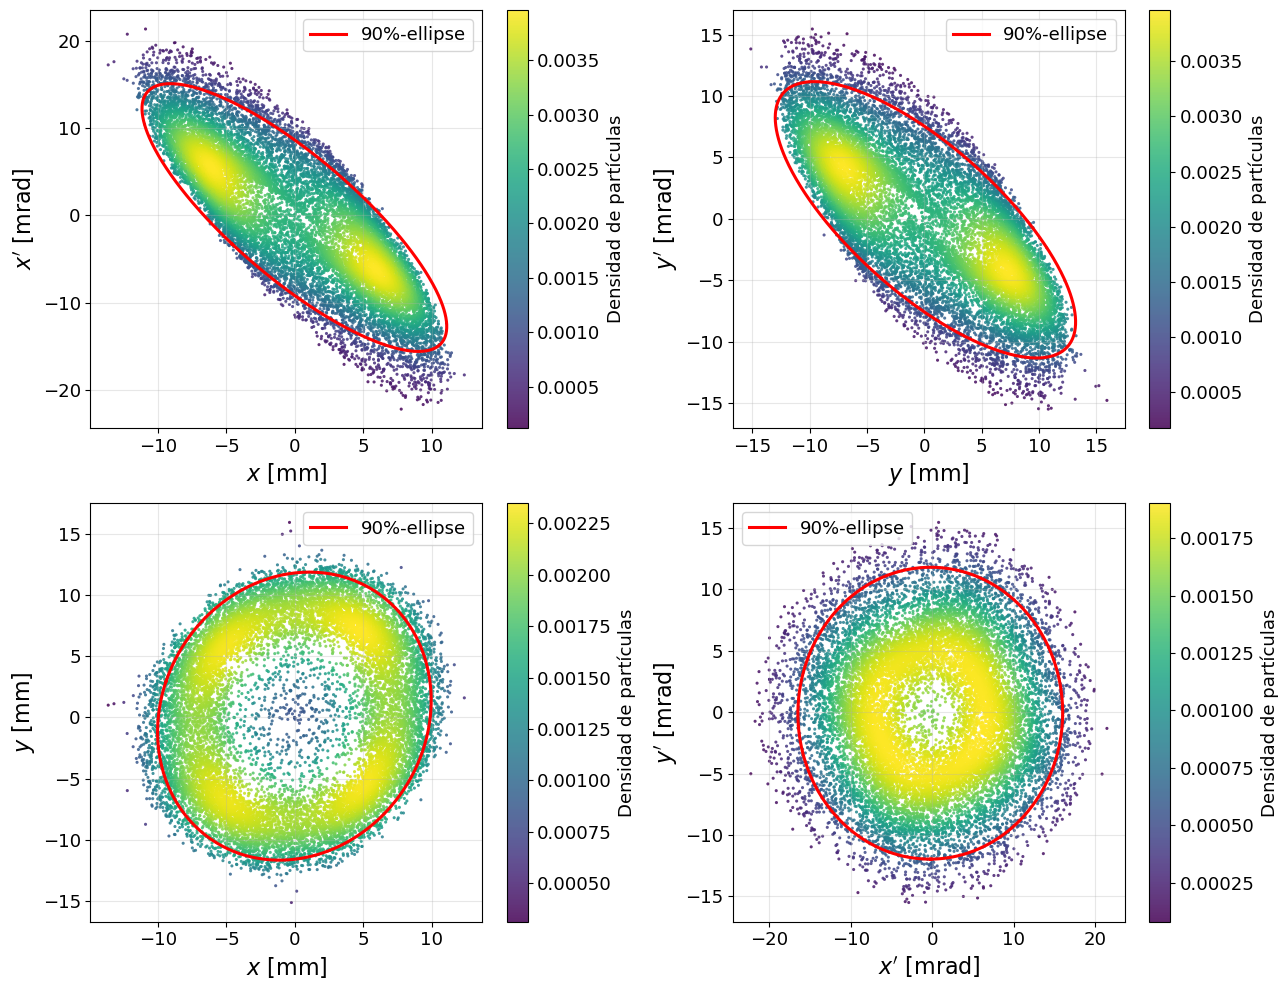

Guardado en: /home/guest/tfm_pedro/Validation-of-linear-ion-accelerator/phase_space_z_k.pdf


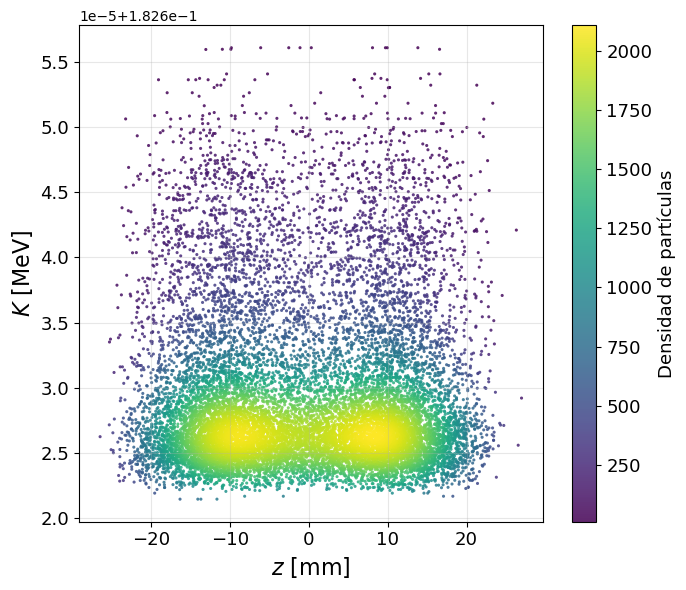

In [24]:
B0T = parser_volume("inputs/beam_outDipole_12C6+.txt")
M0T = B0T.get_phase_space("%X %xp %Y %yp %Z %K")

x  = M0T[:,0]
xp = M0T[:,1]
y  = M0T[:,2]
yp = M0T[:,3]
z  = M0T[:,4]
k  = M0T[:,5]

plot_phase_space_4panel(
    x=x,
    xp=xp,
    y=y,
    yp=yp,
    filename="phase_space_iniciosimulacion",
)

plot_z_k_phase_space(
    z,
    k,
    filename="phase_space_z_k"
)


2613


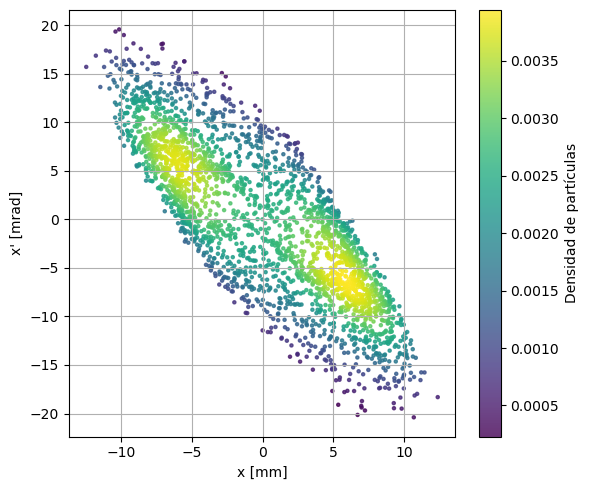

In [25]:
opal_in = np.loadtxt("opal/data/lebt_DISTRIB2.dat", skiprows=2)

x_opal  = opal_in[:, 0] * 1000
px_opal = opal_in[:, 1]
y_opal  = opal_in[:, 2] * 1000
py_opal = opal_in[:, 3]
pz_opal = opal_in[:, 5]
print(len(x_opal))

xp_opal = px_opal / pz_opal * 1000
yp_opal = py_opal / pz_opal * 1000

plot_phase_space(x_opal, xp_opal, "x [mm]", "x' [mrad]")

15673


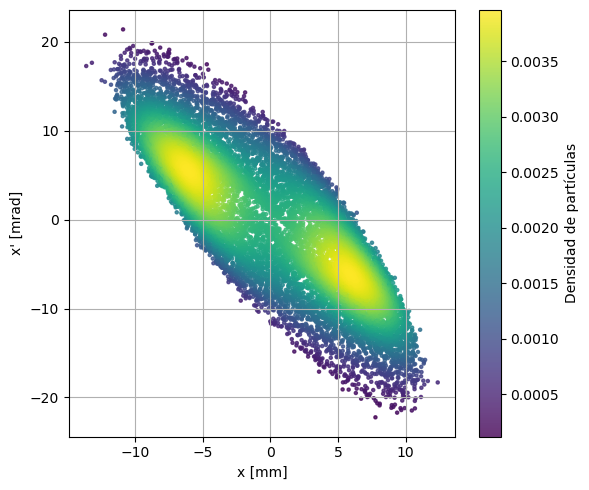

26.97233905609 -26.42739328031


In [26]:
opal_in = np.loadtxt("opal/opal_beam.txt", skiprows=1)

x_opal  = opal_in[:, 0] * 1e3
px_opal = opal_in[:, 1]
y_opal  = opal_in[:, 2] * 1e3
py_opal = opal_in[:, 3]
z_opal  = opal_in[:, 4] * 1e3
pz_opal = opal_in[:, 5]
print(len(x_opal))

xp_opal = px_opal / pz_opal * 1e3
yp_opal = py_opal / pz_opal * 1e3

plot_phase_space(x_opal, xp_opal, "x [mm]", "x' [mrad]")
print(max(z_opal), min(z_opal))


15673


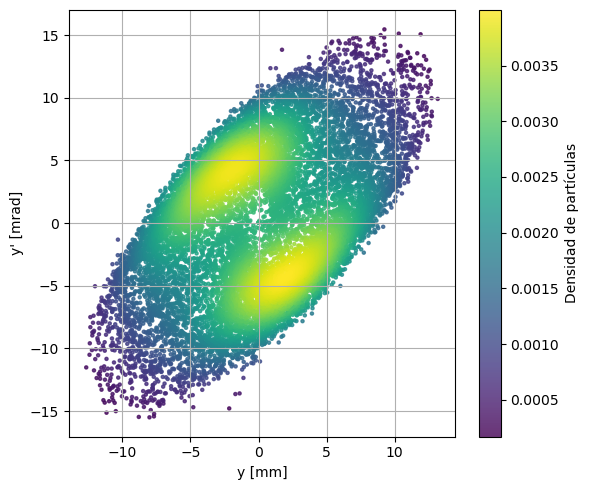

14896


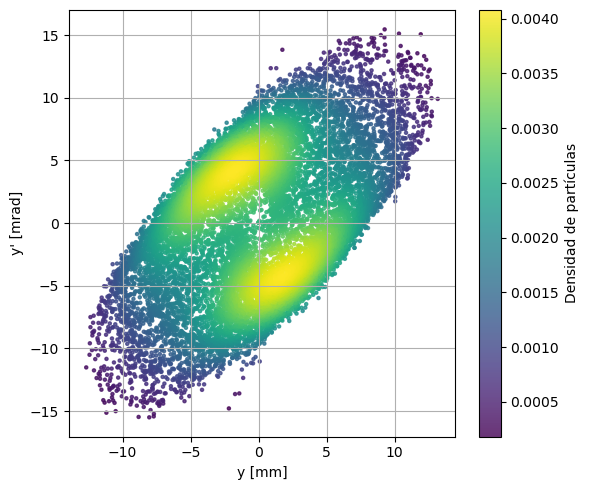

In [27]:
opal_in = np.loadtxt("opal/MONITOR_TEST1.loss", skiprows=1)

x_opal  = opal_in[:, 0] * 1e3
px_opal = opal_in[:, 3]
y_opal  = opal_in[:, 1] * 1e3
py_opal = opal_in[:, 4]
z_opal  = opal_in[:, 2] * 1e3
pz_opal = opal_in[:, 5]
print(len(x_opal))

xp_opal = px_opal / pz_opal * 1e3
yp_opal = py_opal / pz_opal * 1e3

plot_phase_space(y_opal, yp_opal, "y [mm]", "y' [mrad]")

opal_in = np.loadtxt("opal/MONITOR_TEST2.loss", skiprows=1)

x_opal  = opal_in[:, 0] * 1e3
px_opal = opal_in[:, 3]
y_opal  = opal_in[:, 1] * 1e3
py_opal = opal_in[:, 4]
z_opal  = opal_in[:, 2] * 1e3
pz_opal = opal_in[:, 5]
print(len(x_opal))

xp_opal = px_opal / pz_opal * 1e3
yp_opal = py_opal / pz_opal * 1e3

plot_phase_space(y_opal, yp_opal, "y [mm]", "y' [mrad]")